<a href="https://colab.research.google.com/github/MaryAshnaKR/AI/blob/main/Houseprice_predictionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




In [ ]:
df = pd.read_csv("/content/archive (8).zip")
print(df.head())
print(df.info())
print(df.describe())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

In [ ]:

for col in ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']:
    df[col] = df[col].map({'yes':1, 'no':0})


df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("R²:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression Results:
R²: 0.6529242642153185
RMSE: 1324506.9600914384
MAE: 970043.4039201637


In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("R²:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))



Random Forest Results:
R²: 0.6123598247296523
RMSE: 1399769.443949671
MAE: 1014947.3230122325


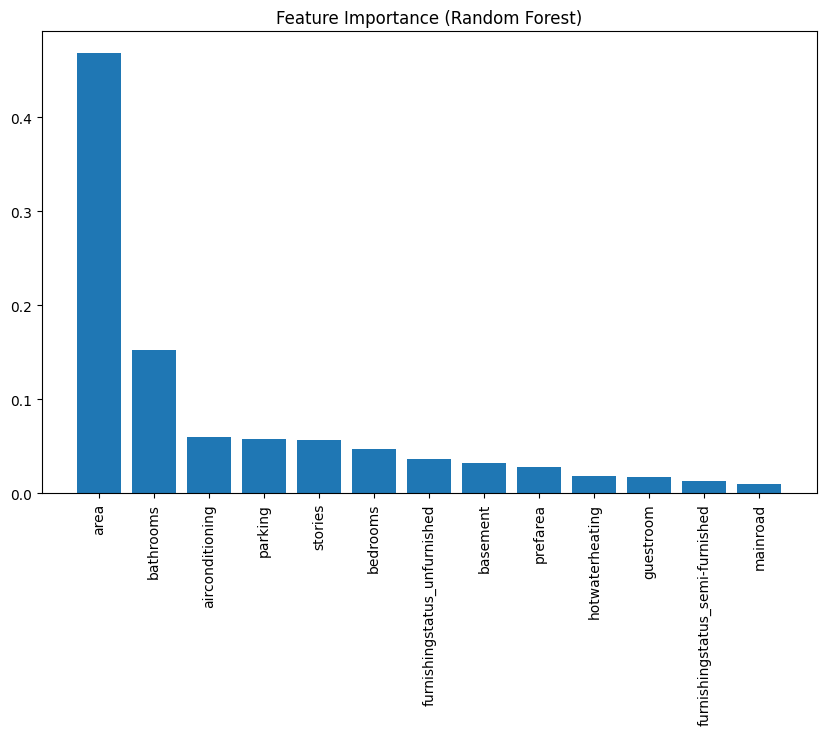

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()


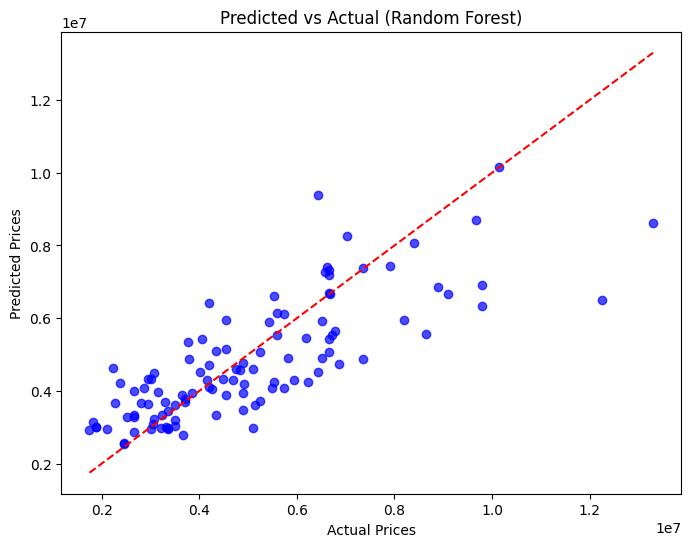

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual (Random Forest)")
plt.show()


In [ ]:
y_log = np.log(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression with Log(price):")
print("R²:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))


Linear Regression with Log(price):
R²: 0.6722047299637579
RMSE: 0.25158214029171816
MAE: 0.19990272792834848


In [ ]:
# Use log-transformed target
y_log = np.log(y)

# Train-test split again with log target
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Random Forest on log(price)
rf_log = RandomForestRegressor(n_estimators=200, random_state=42)
rf_log.fit(X_train, y_train)
y_pred_rf_log = rf_log.predict(X_test)

print("Random Forest with Log(price):")
print("R²:", r2_score(y_test, y_pred_rf_log))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_log)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf_log))

# Back-transform predictions to original scale
y_pred_rf_original = np.exp(y_pred_rf_log)


Random Forest with Log(price):
R²: 0.6313805648623856
RMSE: 0.2667887921584794
MAE: 0.20948792538540942


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best R² Score: 0.6442247959706144


In [ ]:
# Retrain Random Forest with best parameters
rf_best = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=10,
    random_state=42
)

rf_best.fit(X_train, y_train)
y_pred_rf_best = rf_best.predict(X_test)

print("Tuned Random Forest Results:")
print("R²:", r2_score(y_test, y_pred_rf_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_best)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf_best))


Tuned Random Forest Results:
R²: 0.6200271354181164
RMSE: 0.2708661642322068
MAE: 0.21425229472142898


In [ ]:
from xgboost import XGBRegressor


y_log = np.log(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost with Log(price):")
print("R²:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))


y_pred_xgb_original = np.exp(y_pred_xgb)


XGBoost with Log(price):
R²: 0.6193540015025862
RMSE: 0.2711059820450902
MAE: 0.21362184749876287


In [ ]:
results = {
    "Linear Regression (raw)": [0.65, 1324506.96, 970043.40],
    "Random Forest (raw)": [0.61, 1399769.44, 1014947.32],
    "Linear Regression (log)": [0.67, 0.25, 0.20],
    "Random Forest (log)": [0.63, 0.27, 0.21],
    "Random Forest (tuned, log)": [0.62, 0.27, 0.21],
    "XGBoost (log)": [0.62, 0.27, 0.21]
}

df_results = pd.DataFrame(results, index=["R²","RMSE","MAE"]).T
print(df_results)


                              R²        RMSE         MAE
Linear Regression (raw)     0.65  1324506.96   970043.40
Random Forest (raw)         0.61  1399769.44  1014947.32
Linear Regression (log)     0.67        0.25        0.20
Random Forest (log)         0.63        0.27        0.21
Random Forest (tuned, log)  0.62        0.27        0.21
XGBoost (log)               0.62        0.27        0.21


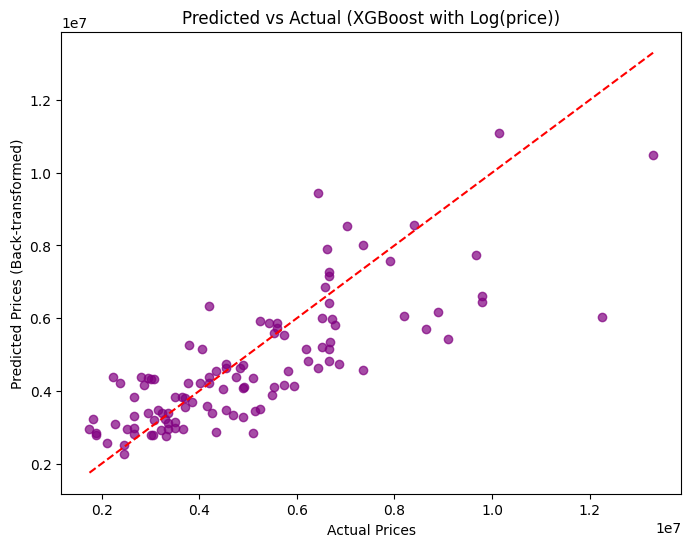

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(np.exp(y_test), y_pred_xgb_original, alpha=0.7, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices (Back-transformed)")
plt.title("Predicted vs Actual (XGBoost with Log(price))")
plt.show()


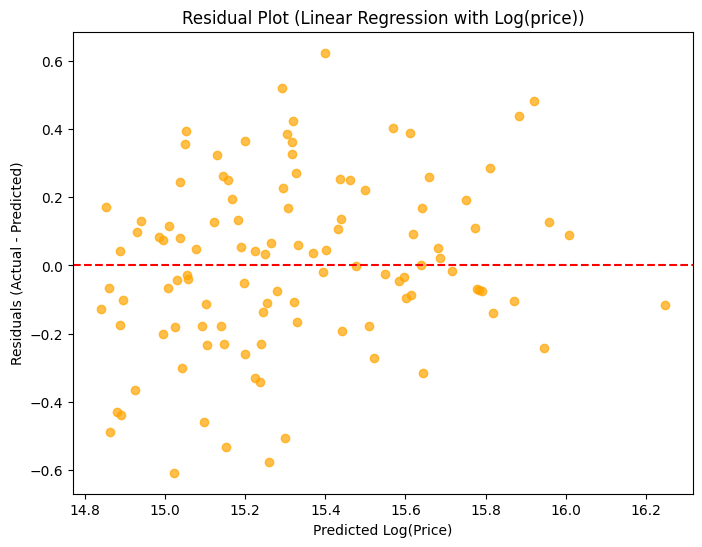

In [ ]:
# Residuals for Linear Regression with log(price)
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,6))
plt.scatter(y_pred_lr, residuals, alpha=0.7, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Log(Price)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression with Log(price))")
plt.show()


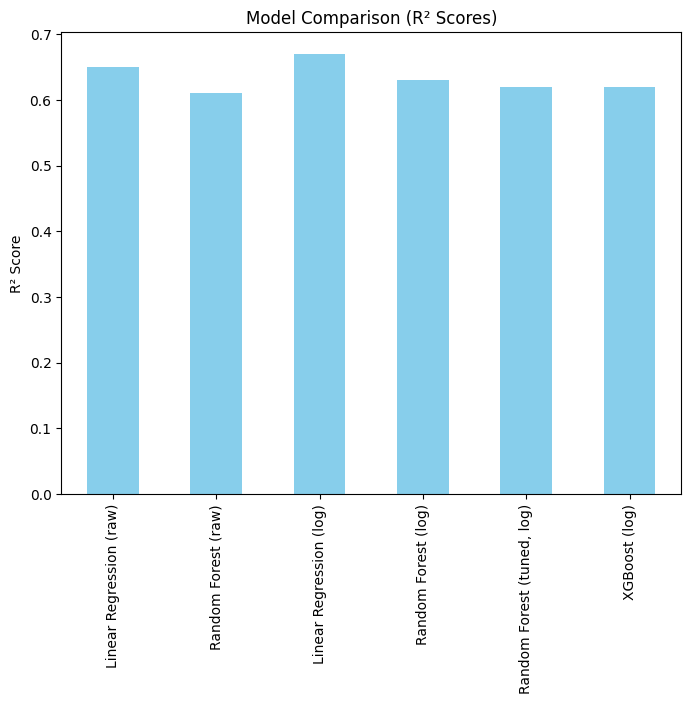

In [ ]:
df_results["R²"].plot(kind="bar", figsize=(8,6), color="skyblue")
plt.ylabel("R² Score")
plt.title("Model Comparison (R² Scores)")
plt.show()


In [ ]:

y_log = np.log(y)
lr_final = LinearRegression()
lr_final.fit(X, y_log)


LinearRegression()

In [ ]:
print(X.columns)


Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')


In [ ]:

new_house_dict = {
    'area': 3000,
    'bedrooms': 4,
    'bathrooms': 3,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 2,
    'prefarea': 0,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 0
}


new_house = pd.DataFrame([new_house_dict], columns=X.columns)

predicted_log_price = lr_final.predict(new_house)

predicted_price = np.exp(predicted_log_price)
print("Predicted House Price:", predicted_price[0])


Predicted House Price: 6391222.27785097


In [ ]:
def predict_house_price(model, X_columns, area, bedrooms, bathrooms, stories,
                        mainroad=1, guestroom=0, basement=0, hotwaterheating=0,
                        airconditioning=1, parking=1, prefarea=0,
                        furnishing="furnished"):

    semi = 1 if furnishing == "semi-furnished" else 0
    unfurnished = 1 if furnishing == "unfurnished" else 0

    new_house_dict = {
        'area': area,
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'stories': stories,
        'mainroad': mainroad,
        'guestroom': guestroom,
        'basement': basement,
        'hotwaterheating': hotwaterheating,
        'airconditioning': airconditioning,
        'parking': parking,
        'prefarea': prefarea,
        'furnishingstatus_semi-furnished': semi,
        'furnishingstatus_unfurnished': unfurnished
    }

    new_house = pd.DataFrame([new_house_dict], columns=X_columns)
    predicted_log_price = model.predict(new_house)
    return float(np.exp(predicted_log_price))


In [ ]:
price = predict_house_price(lr_final, X.columns, 3000, 4, 3, 2, parking=2, furnishing="furnished")
print("Predicted Price:", price)


Predicted Price: 6391222.27785097


/tmp/ipykernel_196/3838744316.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.exp(predicted_log_price))


In [ ]:
houses = [
    {'area': 2500, 'bedrooms': 3, 'bathrooms': 2, 'stories': 2, 'parking': 1, 'furnishing': "semi-furnished"},
    {'area': 4000, 'bedrooms': 5, 'bathrooms': 4, 'stories': 3, 'parking': 2, 'furnishing': "furnished"}
]

for h in houses:
    price = predict_house_price(lr_final, X.columns, **h)
    print("Predicted Price:", price)


Predicted Price: 5006320.76605388
Predicted Price: 8910428.663629768


/tmp/ipykernel_196/3838744316.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.exp(predicted_log_price))
/tmp/ipykernel_196/3838744316.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(np.exp(predicted_log_price))


In [ ]:
importance = pd.Series(lr_final.coef_, index=X.columns)
print(importance.sort_values(ascending=False))


airconditioning                    0.174807
hotwaterheating                    0.163424
bathrooms                          0.163204
prefarea                           0.126751
mainroad                           0.117473
stories                            0.090131
basement                           0.089313
guestroom                          0.069789
parking                            0.044772
bedrooms                           0.029472
furnishingstatus_semi-furnished    0.017969
area                               0.000049
furnishingstatus_unfurnished      -0.109916
dtype: float64
